In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def trace(name, t, show=False, max_items=8):
    """打印 tensor 名字与 shape；小 tensor 可顺带打印内容。"""
    print(f"{name:24s} shape={tuple(t.shape)}  dtype={t.dtype}")
    if show and t.numel() <= max_items * 4:
        print(t)
    return t

## MLP Merger：把「晕人的 reshape」拆成三步看

**核心就两件事：**
1. **2×2 空间打包**：相邻 4 个 patch 的特征 **沿最后一维 concat** → 长度 `4×C`
2. **两层 MLP**：`5120 → 5120 → 3584`（每个打包后的 token 独立过同一个 MLP）

下面先用 **4×4 网格、C=3、patch 编号 0~15** 的小例子，看清「谁和谁被拼在一起」。
HuggingFace 官方实现里 2×2 分组发生在 ViT 的 window 重排阶段，Merger 入口是 `[seq_len, 1280]` 再 `view(-1, 5120)`——**数学等价**，只是写法不同（最后一节对照）。

In [10]:
def show_patch_grid(ids, title="ViT patch 网格（每个格子 = 1 个 patch token）"):
    """ids: [Hp, Wp] 整数编号"""
    Hp, Wp = ids.shape
    fig, ax = plt.subplots(figsize=(Wp * 1.4, Hp * 1.4))
    for r in range(Hp):
        for c in range(Wp):
            ax.add_patch(Rectangle((c, Hp - 1 - r), 1, 1, fill=False, lw=2))
            ax.text(c + 0.5, Hp - 0.5 - r, str(ids[r, c].item()),
                    ha="center", va="center", fontsize=14, fontweight="bold")
    ax.set_xlim(0, Wp)
    ax.set_ylim(0, Hp)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()


def show_merge_groups(ids):
    """画出 2×2 合并后：每个输出 token 对应哪 4 个 patch"""
    Hp, Wp = ids.shape
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    colors = ["#fee2e2", "#dbeafe", "#dcfce7", "#fef9c3"]

    ax = axes[0]
    for r in range(Hp):
        for c in range(Wp):
            g = (r // 2) * (Wp // 2) + (c // 2)
            ax.add_patch(Rectangle((c, Hp - 1 - r), 1, 1, facecolor=colors[g % 4], edgecolor="k", lw=1.5))
            ax.text(c + 0.5, Hp - 0.5 - r, str(ids[r, c].item()), ha="center", va="center", fontsize=13)
    ax.set_xlim(0, Wp); ax.set_ylim(0, Hp); ax.set_aspect("equal")
    ax.set_title("合并前：同色 = 将被 concat 的 2×2 邻域")
    ax.set_xticks([]); ax.set_yticks([])

    ax = axes[1]
    for gr in range(Hp // 2):
        for gc in range(Wp // 2):
            g = gr * (Wp // 2) + gc
            members = ids[gr * 2:(gr + 1) * 2, gc * 2:(gc + 1) * 2].reshape(-1).tolist()
            ax.add_patch(Rectangle((gc, Hp // 2 - 1 - gr), 1, 1, facecolor=colors[g % 4], edgecolor="k", lw=2))
            ax.text(gc + 0.5, Hp // 2 - 0.5 - gr, f"T{g}\n{members}", ha="center", va="center", fontsize=10)
    ax.set_xlim(0, Wp // 2); ax.set_ylim(0, Hp // 2); ax.set_aspect("equal")
    ax.set_title("合并后：1 个 LLM 视觉 token")
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

/data/zhangchangtian/project/modelforge/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/zhangchangtian/project/modelforge/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/zhangchangtian/project/modelforge/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/zhangchangtian/project/modelforge/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/data/zhangchangtian/project/modelfo

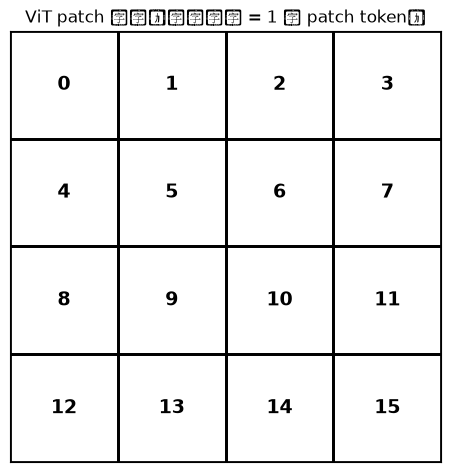

/tmp/ipykernel_2858927/2142052552.py:45: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2858927/2142052552.py:45: UserWarning: Glyph 24182 (\N{CJK UNIFIED IDEOGRAPH-5E76}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2858927/2142052552.py:45: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2858927/2142052552.py:45: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2858927/2142052552.py:45: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2858927/2142052552.py:45: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2858927/2142052552.py:45: UserWarning: Glyph 23558 (\N{CJK UNIFIED IDEOG

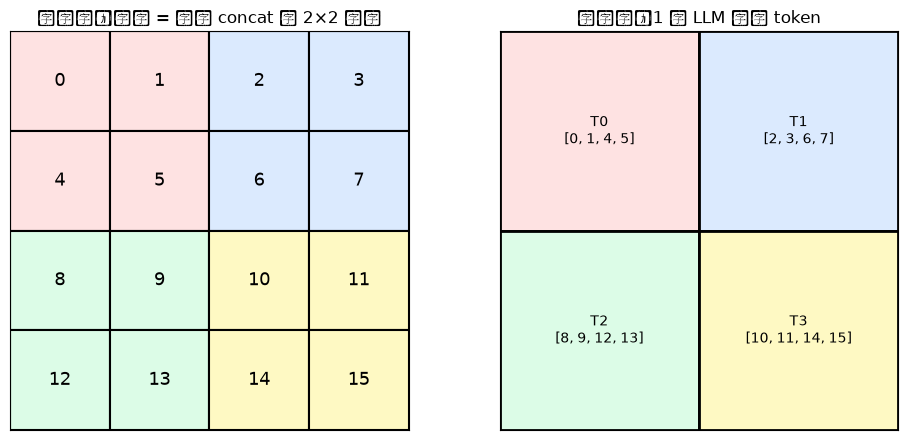

patches                  shape=(1, 4, 4, 3)  dtype=torch.float32


tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00],
          [1.0000e+00, 1.0000e+01, 1.0000e+02],
          [2.0000e+00, 2.0000e+01, 2.0000e+02],
          [3.0000e+00, 3.0000e+01, 3.0000e+02]],

         [[4.0000e+00, 4.0000e+01, 4.0000e+02],
          [5.0000e+00, 5.0000e+01, 5.0000e+02],
          [6.0000e+00, 6.0000e+01, 6.0000e+02],
          [7.0000e+00, 7.0000e+01, 7.0000e+02]],

         [[8.0000e+00, 8.0000e+01, 8.0000e+02],
          [9.0000e+00, 9.0000e+01, 9.0000e+02],
          [1.0000e+01, 1.0000e+02, 1.0000e+03],
          [1.1000e+01, 1.1000e+02, 1.1000e+03]],

         [[1.2000e+01, 1.2000e+02, 1.2000e+03],
          [1.3000e+01, 1.3000e+02, 1.3000e+03],
          [1.4000e+01, 1.4000e+02, 1.4000e+03],
          [1.5000e+01, 1.5000e+02, 1.5000e+03]]]])

In [11]:
# ── 小例子：4×4 patch，每 patch 只有 C=3 维（真实模型 C=1280）──
B, Hp, Wp, C = 1, 4, 4, 3

# 用 patch 编号当特征第 0 维，方便追踪「谁进了哪个 concat」
ids = torch.arange(Hp * Wp).reshape(Hp, Wp)
patches = torch.zeros(B, Hp, Wp, C)
patches[..., 0] = ids.unsqueeze(0).float()          # 第 0 维 = patch id
patches[..., 1] = ids.unsqueeze(0).float() * 10     # 第 1 维 = id×10
patches[..., 2] = ids.unsqueeze(0).float() * 100    # 第 2 维 = id×100

show_patch_grid(ids)
show_merge_groups(ids)

trace("patches", patches)

In [12]:
# ── 逐步 trace：reshape / permute 到底在干什么 ──

# Step 1: 把 H、W 各拆成 (大块, 2) —— 2 就是 2×2 邻域内的行/列偏移
x1 = patches.reshape(B, Hp // 2, 2, Wp // 2, 2, C)
trace("① reshape", x1)
print("  含义: [B, 输出高, 块内行, 输出宽, 块内列, C]")
print("  例如 x1[0,0,*,0,*] 就是左上角 2×2 块里的 4 个 patch")

# Step 2: 把「块内行/列」挪到 concat 前 —— 顺序变为 左上→右上→左下→右下
x2 = x1.permute(0, 1, 3, 2, 4, 5)
trace("② permute", x2)
print("  含义: [B, 输出高, 输出宽, 块内行, 块内列, C]")

# Step 3: 最后两维 (2,2) 与 C 展平 → 4*C
packed = x2.reshape(B, Hp // 2, Wp // 2, 4 * C)
trace("③ packed", packed)

print("\n── 每个输出 token 里 concat 了哪些 patch（看第 0 维=id）──")
for gr in range(Hp // 2):
    for gc in range(Wp // 2):
        vec = packed[0, gr, gc]
        patch_ids = [int(vec[i * C].item()) for i in range(4)]
        print(f"  T{gr * (Wp // 2) + gc} @ ({gr},{gc}): patch ids = {patch_ids}  →  vec[:6]={vec[:6].tolist()}")

① reshape                shape=(1, 2, 2, 2, 2, 3)  dtype=torch.float32
  含义: [B, 输出高, 块内行, 输出宽, 块内列, C]
  例如 x1[0,0,*,0,*] 就是左上角 2×2 块里的 4 个 patch
② permute                shape=(1, 2, 2, 2, 2, 3)  dtype=torch.float32
  含义: [B, 输出高, 输出宽, 块内行, 块内列, C]
③ packed                 shape=(1, 2, 2, 12)  dtype=torch.float32

── 每个输出 token 里 concat 了哪些 patch（看第 0 维=id）──
  T0 @ (0,0): patch ids = [0, 1, 4, 5]  →  vec[:6]=[0.0, 0.0, 0.0, 1.0, 10.0, 100.0]
  T1 @ (0,1): patch ids = [2, 3, 6, 7]  →  vec[:6]=[2.0, 20.0, 200.0, 3.0, 30.0, 300.0]
  T2 @ (1,0): patch ids = [8, 9, 12, 13]  →  vec[:6]=[8.0, 80.0, 800.0, 9.0, 90.0, 900.0]
  T3 @ (1,1): patch ids = [10, 11, 14, 15]  →  vec[:6]=[10.0, 100.0, 1000.0, 11.0, 110.0, 1100.0]


In [13]:
# ── 朴素 for 循环版：与 vectorized 结果必须完全一致 ──

def pack_2x2_naive(patches):
    B, Hp, Wp, C = patches.shape
    out = torch.zeros(B, Hp // 2, Wp // 2, 4 * C)
    for gr in range(Hp // 2):
        for gc in range(Wp // 2):
            block = patches[:, gr * 2:(gr + 1) * 2, gc * 2:(gc + 1) * 2, :]  # [B,2,2,C]
            # 顺序：左上、右上、左下、右下（与 permute+reshape 一致）
            vecs = [block[:, 0, 0], block[:, 0, 1], block[:, 1, 0], block[:, 1, 1]]
            out[:, gr, gc] = torch.cat(vecs, dim=-1)
    return out

naive = pack_2x2_naive(patches)
assert torch.allclose(naive, packed), "vectorized 与 naive 不一致！"
print("✓ vectorized reshape/permute 与 for 循环 2×2 concat 完全一致")

✓ vectorized reshape/permute 与 for 循环 2×2 concat 完全一致


### MLP：把「一个 token」当成一行向量做矩阵乘法

`packed` 形状 `[B, H_out, W_out, 5120]`。`nn.Linear` 只对**最后一维**做运算，前面维度都是 batch 维。

对**单个**合并 token（行向量 `x`，长度 5120）：

$$
h = \mathrm{GELU}(x W_1^\top + b_1), \quad y = h W_2^\top + b_2
$$

其中 $W_1 \in \mathbb{R}^{5120 \times 5120}$，$W_2 \in \mathbb{R}^{3584 \times 5120}$。

In [14]:
# 用小维度演示 MLP 矩阵运算（C=3 → 4*C=12，便于肉眼看）
vit_hidden, llm_hidden = 3, 5
in_dim = vit_hidden * 4

W1 = torch.arange(in_dim * in_dim, dtype=torch.float32).reshape(in_dim, in_dim) * 0.001
b1 = torch.zeros(in_dim)
W2 = torch.arange(in_dim * llm_hidden, dtype=torch.float32).reshape(llm_hidden, in_dim) * 0.001
b2 = torch.zeros(llm_hidden)

x = packed[0, 0, 0]  # 第一个合并 token，长度 12
trace("x (一个 token)", x)

h_pre = x @ W1.T + b1
trace("h_pre = x @ W1.T + b1", h_pre)
h = F.gelu(h_pre)
trace("h = GELU(h_pre)", h)
y = h @ W2.T + b2
trace("y = h @ W2.T + b2  →  LLM token", y)

# 与 nn.Linear 堆叠对比
mlp = nn.Sequential(nn.Linear(in_dim, in_dim), nn.GELU(), nn.Linear(in_dim, llm_hidden))
with torch.no_grad():
    mlp[0].weight.copy_(W1)
    mlp[0].bias.copy_(b1)
    mlp[2].weight.copy_(W2)
    mlp[2].bias.copy_(b2)
assert torch.allclose(y, mlp(x)), "手算与 nn.Linear 不一致"
print("✓ 手算 matmul 与 nn.Sequential 一致")

x (一个 token)             shape=(12,)  dtype=torch.float32
h_pre = x @ W1.T + b1    shape=(12,)  dtype=torch.float32
h = GELU(h_pre)          shape=(12,)  dtype=torch.float32
y = h @ W2.T + b2  →  LLM token shape=(5,)  dtype=torch.float32
✓ 手算 matmul 与 nn.Sequential 一致


In [ ]:
class MLPMerger(nn.Module):
    """教学版：先 2×2 pack，再 MLP（报告写法；HF 见下一 cell）"""

    def __init__(self, vit_hidden=1280, llm_hidden=3584):
        super().__init__()
        in_dim = vit_hidden * 4
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.GELU(),  # HF 官方用 GELU；报告有时写 SiLU
            nn.Linear(in_dim, llm_hidden),
        )

    def pack_2x2(self, patches):
        B, Hp, Wp, C = patches.shape
        x = patches.reshape(B, Hp // 2, 2, Wp // 2, 2, C)
        x = x.permute(0, 1, 3, 2, 4, 5).reshape(B, Hp // 2, Wp // 2, 4 * C)
        return x

    def forward(self, patches, trace_steps=False):
        packed = self.pack_2x2(patches)
        if trace_steps:
            trace("packed", packed)
            flat = packed.reshape(-1, packed.shape[-1])
            trace("flat (MLP 实际看到的)", flat)
            h = self.mlp[0](flat); trace("after Linear1", h)
            h = self.mlp[1](h);   trace("after GELU", h)
            out = self.mlp[2](h); trace("after Linear2 → LLM dim", out)
            return out.reshape(*packed.shape[:-1], -1)
        return self.mlp(packed)


# 真实尺寸走一遍 shape（随机权重，只看维度）
merger = MLPMerger(vit_hidden=1280, llm_hidden=3584)
fake = torch.randn(1, 56, 56, 1280)  # 例如 784×784 图像 → 56×56 patch
out = merger(fake, trace_steps=True)
print(f"\n输入 patch 数: {56*56}  →  输出 LLM token 数: {56//2 * 56//2}  (压缩 4×)")

### HuggingFace 官方写法（`Qwen2_5_VLPatchMerger`）

ViT 输出已是 `[seq_len, 1280]`（每个 patch 一行）。**2×2 分组**在 ViT 的 window 重排里完成；Merger 里只剩：

```python
x = ln_q(x).view(-1, 1280 * 4)   # 每连续 4 行 concat → [seq_len/4, 5120]
x = mlp(x)                        # [seq_len/4, 3584]
```

与上面的 `pack_2x2` **数学相同**：都是把 4 个 patch 特征拼成 5120 维，再过同一个 MLP。

In [ ]:
# HF 风格：seq_len 行 patch，每 4 行一组（已按空间 2×2 排好序）
seq_len, vit_hidden, llm_hidden = 16, 3, 5
x_seq = packed.reshape(seq_len, vit_hidden)  # 16 个 patch，每个 3 维
trace("x_seq (ViT 输出)", x_seq)

# view(-1, 4*C) 等价于每 4 行 concat 最后一维
x_hf = x_seq.view(-1, 4 * vit_hidden)
trace("x_hf after view(-1, 4*C)", x_hf)

# 与 pack_2x2 输出 flatten 对比
flat_teaching = packed.reshape(-1, 4 * vit_hidden)
assert torch.allclose(x_hf, flat_teaching), "HF view 与 pack_2x2 不一致"
print("✓ HF 的 view(-1, 5120) 与教学版 pack_2x2 一致")
print(f"  {seq_len} patch → {seq_len // 4} 个 LLM 视觉 token")